Lilian Scicluna

Question : Quel était le classement des pilotes à l’issue de la saison 2023 ?

Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

Chargement des données

In [2]:
drivers = pd.read_csv("donnees_formule_un/drivers.csv")
results = pd.read_csv("donnees_formule_un/results.csv")
races = pd.read_csv("donnees_formule_un/races.csv")

Courses de la saison 2023

In [3]:
races_2023 = races[races['year'] == 2023]
race_ids_2023 = races_2023['raceId'].tolist()

Résultats de 2023

In [4]:
results_2023 = results[results['raceId'].isin(race_ids_2023)].copy()

Total de points par pilote

In [5]:
points_per_driver = results_2023.groupby('driverId')['points'].sum().reset_index(name='total_points')


Comptage des positions (1er, 2e, etc.)

In [6]:
results_2023['positionOrder'] = pd.to_numeric(results_2023['positionOrder'], errors='coerce')

position_counts = results_2023.pivot_table(
    index='driverId',
    columns='positionOrder',
    aggfunc='size',
    fill_value=0
)

position_counts.columns = [f'pos_{int(col)}' for col in position_counts.columns]


Fusion des données

In [7]:
ranking_data = points_per_driver.merge(position_counts, on='driverId', how='left')
ranking_data = ranking_data.merge(drivers[['driverId', 'forename', 'surname']], on='driverId')


Tri du classement avec gestion des égalités

In [8]:
columns_to_display = ['rank', 'forename', 'surname', 'total_points'] + \
    [col for col in ranking_data.columns if col.startswith('pos_')]
sort_columns = ['total_points'] + [f'pos_{i}' for i in range(1, 11) if f'pos_{i}' in ranking_data.columns]
ranking_data = ranking_data.sort_values(by=sort_columns, ascending=[False]*len(sort_columns))
ranking_data['rank'] = range(1, len(ranking_data) + 1)
ranking_final_2023 = ranking_data[columns_to_display]


Affichage du classement final

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_8420\524566387.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_8420\524566387.py:8: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


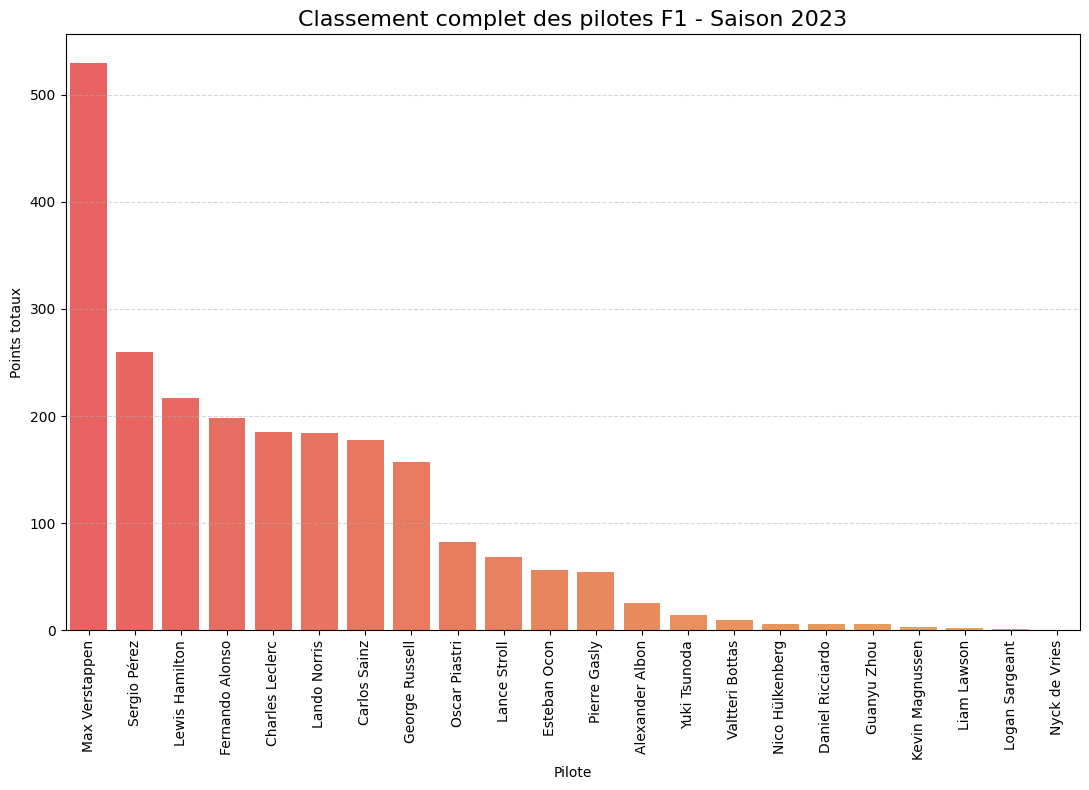

In [9]:
ranking_final_2023['FullName'] = ranking_final_2023['forename'] + ' ' + ranking_final_2023['surname']
ranking_final_2023_sorted = ranking_final_2023.sort_values(by='rank')

red_orange = LinearSegmentedColormap.from_list("red_orange", ["#ff4c4c", "#ffae42"])

plt.figure(figsize=(max(8, 0.5 * len(ranking_final_2023_sorted)), 8))

sns.barplot(
    data=ranking_final_2023_sorted,
    x='FullName',
    y='total_points',
    palette=red_orange(np.linspace(0, 1, len(ranking_final_2023_sorted)))
)

plt.title("Classement complet des pilotes F1 - Saison 2023", fontsize=16)
plt.ylabel("Points totaux")
plt.xlabel("Pilote")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



Question 2 : Quels sont les pilotes et les écuries avec le plus d'abandons (Python sans imports)

 Identifier les statusId correspondant à un abandon

In [10]:
# On repère les types d'abandon dans status.csv
abandon_keywords = [
    "Accident", "Collision", "Engine", "Gearbox", "Hydraulics", "Electrical",
    "Suspension", "Retired", "Overheating", "Fuel", "Brake", "Wheel", "Transmission",
    "Power Unit", "Clutch", "Driveshaft", "Exhaust", "Oil Leak", "Fire"
]

abandon_status_ids = set()

with open("donnees_formule_un/status.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()
    header = lines[0].strip().split(",")
    for line in lines[1:]:
        parts = line.strip().split(",", 1)
        if len(parts) < 2:
            continue
        status_id, status_label = parts
        for keyword in abandon_keywords:
            if keyword.lower() in status_label.lower():
                abandon_status_ids.add(status_id)
                break


Compter les abandons par pilote et par écurie

In [11]:
pilot_abandons = {}
constructor_abandons = {}

with open("donnees_formule_un/results.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()
    header = lines[0].strip().split(",")
    driver_id_index = header.index("driverId")
    constructor_id_index = header.index("constructorId")
    status_id_index = header.index("statusId")

    for line in lines[1:]:
        parts = line.strip().split(",")
        if len(parts) <= max(driver_id_index, constructor_id_index, status_id_index):
            continue
        driver_id = parts[driver_id_index]
        constructor_id = parts[constructor_id_index]
        status_id = parts[status_id_index]

        if status_id in abandon_status_ids:
            if driver_id not in pilot_abandons:
                pilot_abandons[driver_id] = 0
            pilot_abandons[driver_id] += 1

            if constructor_id not in constructor_abandons:
                constructor_abandons[constructor_id] = 0
            constructor_abandons[constructor_id] += 1


Lier les pilotes à leurs noms

In [12]:
driver_names = {}

with open("donnees_formule_un/drivers.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()
    header = lines[0].strip().split(",")
    id_index = header.index("driverId")
    fname_index = header.index("forename")
    lname_index = header.index("surname")

    for line in lines[1:]:
        parts = line.strip().split(",")
        if len(parts) > max(id_index, fname_index, lname_index):
            driver_id = parts[id_index]
            name = parts[fname_index] + " " + parts[lname_index]
            driver_names[driver_id] = name


Lier les écuries à leurs noms

In [13]:
constructor_names = {}

with open("donnees_formule_un/constructors.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()
    header = lines[0].strip().split(",")
    id_index = header.index("constructorId")
    name_index = header.index("name")

    for line in lines[1:]:
        parts = line.strip().split(",")
        if len(parts) > max(id_index, name_index):
            constructor_id = parts[id_index]
            name = parts[name_index]
            constructor_names[constructor_id] = name


Affichage du top pilotes et écuries

In [14]:
sorted_pilots = sorted(pilot_abandons.items(), key=lambda x: x[1], reverse=True)
sorted_constructors = sorted(constructor_abandons.items(), key=lambda x: x[1], reverse=True)

print("Top 10 pilotes avec le plus d'abandons :\n")
for driver_id, count in sorted_pilots[:10]:
    name = driver_names.get(driver_id, f"Pilote inconnu (ID {driver_id})")
    print(f"{name}: {count} abandons")

print("\nTop 10 écuries avec le plus d'abandons :\n")
for constructor_id, count in sorted_constructors[:10]:
    name = constructor_names.get(constructor_id, f"Écurie inconnue (ID {constructor_id})")
    print(f"{name}: {count} abandons")


Top 10 pilotes avec le plus d'abandons :

"Andrea" "de Cesaris": 101 abandons
"Riccardo" "Patrese": 101 abandons
"Michele" "Alboreto": 85 abandons
"Jarno" "Trulli": 80 abandons
"Rubens" "Barrichello": 76 abandons
"Gerhard" "Berger": 72 abandons
"Jean" "Alesi": 70 abandons
"Nigel" "Mansell": 66 abandons
"David" "Coulthard": 65 abandons
"Mario" "Andretti": 65 abandons

Top 10 écuries avec le plus d'abandons :

"Ferrari": 544 abandons
"McLaren": 451 abandons
"Williams": 374 abandons
"Team Lotus": 317 abandons
"Tyrrell": 291 abandons
"Brabham": 244 abandons
"Minardi": 241 abandons
"BRM": 211 abandons
"Arrows": 208 abandons
"March": 207 abandons


OBJECTIF : prédire le total de points d’un pilote à partir de ses classements (1e, 2e, 3e places, etc.)

Imports pour la régression

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

Sélection des variables explicatives X et de la cible y

In [16]:
# On garde uniquement les colonnes des positions (1e, 2e, ..., 10e)
position_cols = [col for col in ranking_data.columns if col.startswith("pos_")]
X = ranking_data[position_cols]
y = ranking_data["total_points"]
# ➡️ Nouveau : on récupère le FullName à partir du driverId
pilot_identity = ranking_data[["driverId"]].copy()
pilot_identity = pilot_identity.merge(
    drivers[["driverId", "forename", "surname"]],
    on="driverId",
    how="left"
)
pilot_identity["FullName"] = pilot_identity["forename"] + " " + pilot_identity["surname"]

# Récupérer la colonne des noms complets
full_names = pilot_identity["FullName"]


Séparation en données d'entraînement et de test

In [17]:
X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X, y, full_names, test_size=0.2, random_state=42
)

Entraînement du modèle de régression linéaire

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Prédictions et évaluation

In [19]:
y_pred = model.predict(X_test)



# Évaluation
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Évaluation du modèle :")
print(f"RMSE : {rmse:.2f}")
print(f"Score R² : {r2:.3f}")

Évaluation du modèle :
RMSE : 162.82
Score R² : 0.325


Comparaison prédiction / réalité

In [20]:
import pandas as pd

# On affiche quelques résultats pour voir comment le modèle se débrouille
comparison = pd.DataFrame({
    "Réel": y_test.values,
    "Prédit": y_pred.round(1)
})
print(comparison.head(10))


    Réel  Prédit
0  530.0   171.2
1   14.0    -7.9
2   82.0    81.8
3  260.0   202.8
4    6.0    -1.5


Afficher les coefficients

In [21]:
# On regarde le poids de chaque variable (chaque position)
coeffs = pd.DataFrame({
    "Position": X.columns,
    "Coefficient": model.coef_.round(2)
}).sort_values(by="Coefficient", ascending=False)

print(coeffs)

   Position  Coefficient
2     pos_3        17.65
1     pos_2        15.78
4     pos_5        11.88
5     pos_6         8.51
6     pos_7         6.80
0     pos_1         6.49
3     pos_4         6.42
7     pos_8         5.61
19   pos_20         3.94
12   pos_13         3.37
18   pos_19         2.28
11   pos_12         1.80
8     pos_9         0.78
16   pos_17         0.12
13   pos_14        -0.87
9    pos_10        -0.93
17   pos_18        -1.31
15   pos_16        -2.59
10   pos_11        -3.34
14   pos_15        -5.16


Total de courses par pilote

In [22]:
# On compte combien de courses chaque pilote a faites en 2023
races_per_driver = results_2023.groupby("driverId").size().reset_index(name="total_races")

# On fusionne avec ranking_data
ranking_data = ranking_data.merge(races_per_driver, on="driverId", how="left")

Nombre d’abandons par pilote

In [23]:
# On récupère les status d'abandon depuis status.csv
status_df = pd.read_csv("donnees_formule_un/status.csv")

# On repère les statusIds d'abandon
abandon_keywords = ["Accident", "Collision", "Engine", "Gearbox", "Retired", "Fire", "Electrical",
                    "Suspension", "Overheating", "Clutch", "Hydraulics", "Brake", "Oil", "Fuel"]

abandon_ids = status_df[status_df["status"].str.contains('|'.join(abandon_keywords), case=False)]["statusId"].astype(str).tolist()

# On compte le nombre d'abandons par pilote
abandons_per_driver = results_2023[results_2023["statusId"].astype(str).isin(abandon_ids)] \
    .groupby("driverId").size().reset_index(name="nb_abandons")

# Merge dans ranking_data
ranking_data = ranking_data.merge(abandons_per_driver, on="driverId", how="left")
ranking_data["nb_abandons"] = ranking_data["nb_abandons"].fillna(0)

Position moyenne à l’arrivée

In [24]:
# Calcul de la position moyenne d’arrivée
pos_avg_driver = results_2023.groupby("driverId")["positionOrder"].mean().reset_index(name="pos_avg")

# Merge dans ranking_data
ranking_data = ranking_data.merge(pos_avg_driver, on="driverId", how="left")

Relancer le modèle 

In [25]:
X = ranking_data[position_cols + ["total_races", "nb_abandons", "pos_avg"]]

Préparer X et y avec les nouvelles colonnes

In [26]:
# Variables explicatives : positions + nouvelles features
position_cols = [col for col in ranking_data.columns if col.startswith("pos_")]
features = position_cols + ["total_races", "nb_abandons", "pos_avg"]

X = ranking_data[features]
y = ranking_data["total_points"]

Split train/test

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Entraînement du modèle

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

Prédiction + évaluation du modèle

In [29]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Évaluation du modèle enrichi :")
print(f"RMSE : {rmse:.2f}")
print(f"Score R² : {r2:.3f}")


Évaluation du modèle enrichi :
RMSE : 118.39
Score R² : 0.643


Comparaison Prédit / Réel

In [30]:
import pandas as pd

comparison = pd.DataFrame({
    "Réel": y_test.values,
    "Prédit": y_pred.round(1)
})
print(comparison.head(10))


    Réel  Prédit
0  530.0   267.2
1   14.0     4.0
2   82.0    79.3
3  260.0   231.6
4    6.0    15.8


Coefficients des variables

In [31]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_.round(2)
}).sort_values(by="Coefficient", ascending=False)

print("Influence des variables sur les points prédits :")
print(coeffs)


Influence des variables sur les points prédits :
        Feature  Coefficient
1         pos_2         9.29
2         pos_3         8.99
5         pos_6         3.45
21  total_races         3.01
4         pos_5         3.00
3         pos_4         2.95
19       pos_20         2.76
0         pos_1         2.36
13       pos_14         2.35
22  nb_abandons         0.60
17       pos_18        -0.11
16       pos_17        -0.58
6         pos_7        -1.15
11       pos_12        -1.41
18       pos_19        -1.84
7         pos_8        -2.06
14       pos_15        -2.28
12       pos_13        -2.77
15       pos_16        -3.48
8         pos_9        -4.68
9        pos_10        -5.75
20      pos_avg        -5.83
23      pos_avg        -5.83
10       pos_11        -6.04


In [32]:

# 🏁 Classement des pilotes à l’issue de la saison 2023

# Identifier les courses de 2023
races_2023 = races[races["year"] == 2023]
race_ids_2023 = races_2023["raceId"].tolist()

# Filtrer les résultats 2023
results_2023 = results[results["raceId"].isin(race_ids_2023)].copy()

# Points totaux
points_per_driver = results_2023.groupby("driverId")["points"].sum().reset_index(name="total_points")

# Comptage des positions (1 à 10)
results_2023["positionOrder"] = pd.to_numeric(results_2023["positionOrder"], errors="coerce")
position_counts = results_2023.pivot_table(index="driverId", columns="positionOrder", aggfunc="size", fill_value=0)
position_counts.columns = [f"pos_{int(col)}" for col in position_counts.columns]

# Fusion
ranking_data = points_per_driver.merge(position_counts, on="driverId", how="left")
ranking_data = ranking_data.merge(drivers[["driverId", "forename", "surname"]], on="driverId")
sort_columns = ["total_points"] + [f"pos_{i}" for i in range(1, 11) if f"pos_{i}" in ranking_data.columns]
ranking_data = ranking_data.sort_values(by=sort_columns, ascending=[False] * len(sort_columns))
ranking_data["rank"] = range(1, len(ranking_data) + 1)

# Colonnes finales
columns_to_display = ["rank", "forename", "surname", "total_points"] + [col for col in ranking_data.columns if col.startswith("pos_")]
ranking_final_2023 = ranking_data[columns_to_display]
ranking_final_2023


,rank,forename,surname,total_points,pos_1,pos_2,pos_3,pos_4,pos_5,pos_6,...,pos_11,pos_12,pos_13,pos_14,pos_15,pos_16,pos_17,pos_18,pos_19,pos_20
7,1,Max,Verstappen,530.0,19,2,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2,Sergio,Pérez,260.0,2,4,3,5,1,2,...,0,0,0,0,0,1,0,0,1,1
0,3,Lewis,Hamilton,217.0,0,3,3,3,3,4,...,0,0,0,0,0,0,0,0,2,0
1,4,Fernando,Alonso,198.0,0,3,5,1,2,1,...,0,0,0,0,1,1,0,1,0,0
12,5,Charles,Leclerc,185.0,0,3,3,4,1,1,...,1,0,0,0,0,0,0,0,2,3
13,6,Lando,Norris,184.0,0,6,1,1,2,1,...,0,0,1,0,0,0,4,0,0,1
8,7,Carlos,Sainz,178.0,1,0,2,2,5,5,...,0,1,0,0,0,0,0,1,1,1
14,8,George,Russell,157.0,0,0,2,3,4,3,...,0,0,0,0,1,1,1,1,1,0
19,9,Oscar,Piastri,82.0,0,1,1,1,1,1,...,2,1,1,1,1,1,1,0,1,2
10,10,Lance,Stroll,68.0,0,0,0,1,2,2,...,2,1,0,1,0,1,1,1,0,3


In [33]:

# 🚨 Nombre d’abandons par pilote et par écurie

# Identifier les statusId d’abandon
status_df = pd.read_csv("donnees_formule_un/status.csv")
abandon_keywords = ["Accident", "Collision", "Engine", "Gearbox", "Retired", "Fire", "Electrical",
                    "Suspension", "Overheating", "Clutch", "Hydraulics", "Brake", "Oil", "Fuel"]
abandon_ids = status_df[status_df["status"].str.contains('|'.join(abandon_keywords), case=False)]["statusId"].astype(str).tolist()

# Abandons pilotes
abandons_pilotes = results_2023[results_2023["statusId"].astype(str).isin(abandon_ids)]     .groupby("driverId").size().reset_index(name="nb_abandons")
abandons_pilotes = abandons_pilotes.merge(drivers[["driverId", "forename", "surname"]], on="driverId")
abandons_pilotes = abandons_pilotes.sort_values(by="nb_abandons", ascending=False)

# Abandons écuries
abandons_ecuries = results_2023[results_2023["statusId"].astype(str).isin(abandon_ids)]     .groupby("constructorId").size().reset_index(name="nb_abandons")
abandons_ecuries = abandons_ecuries.merge(constructors[["constructorId", "name"]], on="constructorId")
abandons_ecuries = abandons_ecuries.sort_values(by="nb_abandons", ascending=False)

abandons_pilotes.head(10), abandons_ecuries.head(10)


NameError: name 'constructors' is not defined

In [34]:

# 🔧 Ajouter le nombre total de courses par pilote (2023)
races_per_driver = results_2023.groupby("driverId").size().reset_index(name="total_races")
ranking_data = ranking_data.merge(races_per_driver, on="driverId", how="left")


In [35]:

# 🔧 Ajouter le nombre d'abandons par pilote (2023)
status_df = pd.read_csv("donnees_formule_un/status.csv")
abandon_keywords = ["Accident", "Collision", "Engine", "Gearbox", "Retired", "Fire", "Electrical",
                    "Suspension", "Overheating", "Clutch", "Hydraulics", "Brake", "Oil", "Fuel"]
abandon_ids = status_df[status_df["status"].str.contains('|'.join(abandon_keywords), case=False)]["statusId"].astype(str).tolist()

abandons_per_driver = results_2023[results_2023["statusId"].astype(str).isin(abandon_ids)]     .groupby("driverId").size().reset_index(name="nb_abandons")

ranking_data = ranking_data.merge(abandons_per_driver, on="driverId", how="left")
ranking_data["nb_abandons"] = ranking_data["nb_abandons"].fillna(0)


In [36]:

# 🔧 Ajouter la position moyenne à l’arrivée
pos_avg_driver = results_2023.groupby("driverId")["positionOrder"].mean().reset_index(name="pos_avg")
ranking_data = ranking_data.merge(pos_avg_driver, on="driverId", how="left")


✅ Évaluation du modèle enrichi :
RMSE : 17.83
Score R² : 0.909
          FullName   Réel  Prédit
0   George Russell  157.0   163.9
1     Esteban Ocon   56.0    54.3
4  Valtteri Bottas   10.0    10.1
3  Nico Hülkenberg    6.0     8.8
2    Nyck de Vries    0.0   -39.1


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_8420\3749096139.py:63: UserWarning: Glyph 127950 (\N{RACING CAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\34lil\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127950 (\N{RACING CAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


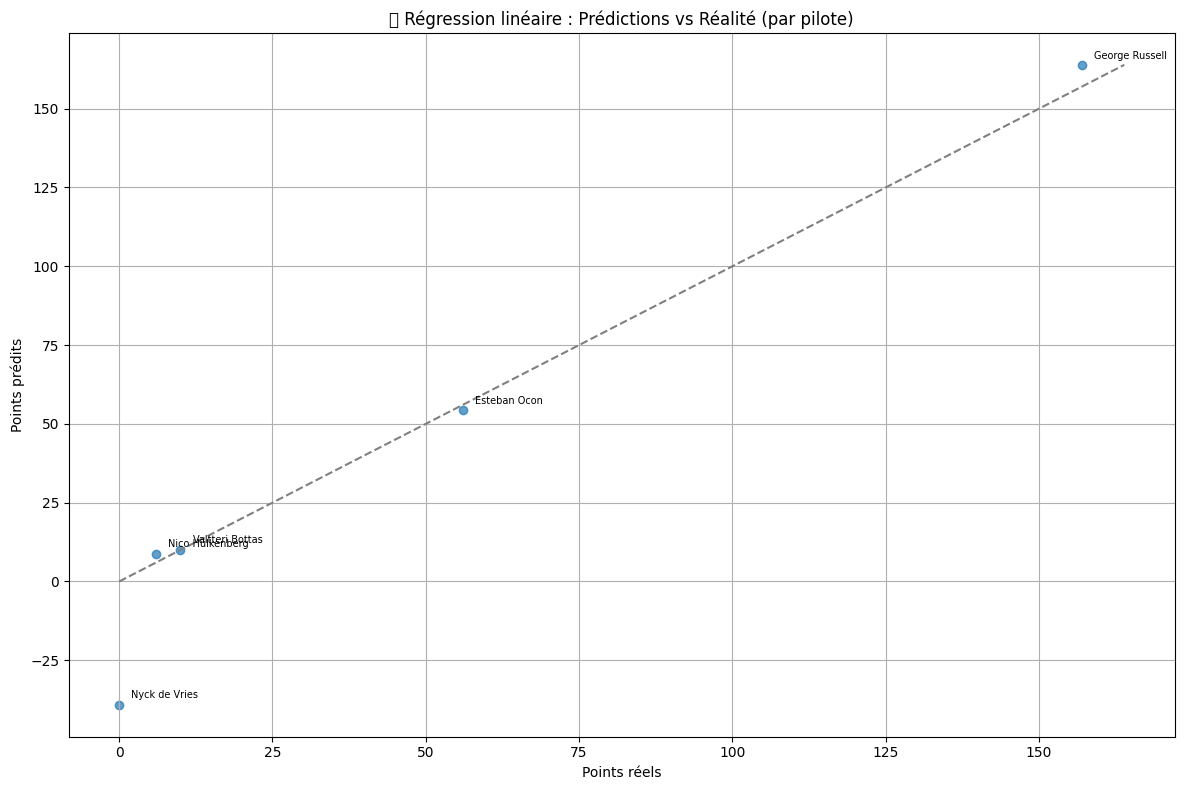

In [39]:

# 📊 Régression linéaire enrichie : prédire les points d’un pilote

# Variables explicatives et cible
position_cols = [col for col in ranking_data.columns if col.startswith("pos_")]
features = position_cols + ["total_races", "nb_abandons", "pos_avg"]
X = ranking_data[features]
y = ranking_data["total_points"]

# Récupérer les noms complets
pilot_identity = ranking_data[["driverId"]].copy()
pilot_identity = pilot_identity.merge(
    drivers[["driverId", "forename", "surname"]],
    on="driverId",
    how="left"
)
pilot_identity["FullName"] = pilot_identity["forename"] + " " + pilot_identity["surname"]
full_names = pilot_identity["FullName"]

# Séparation
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X, y, full_names, test_size=0.2, random_state=12
)

# Modèle
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Évaluation
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("✅ Évaluation du modèle enrichi :")
print(f"RMSE : {rmse:.2f}")
print(f"Score R² : {r2:.3f}")

# Comparaison
comparison = pd.DataFrame({
    "FullName": names_test.values,
    "Réel": y_test.values,
    "Prédit": y_pred.round(1)
})
print(comparison.sort_values(by="Réel", ascending=False).head(10))

# Scatterplot
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.scatter(comparison["Réel"], comparison["Prédit"], alpha=0.7)
for i in range(len(comparison)):
    plt.text(comparison["Réel"].iloc[i]+2, comparison["Prédit"].iloc[i]+2,
             comparison["FullName"].iloc[i], fontsize=7)
plt.plot([0, max(comparison["Réel"].max(), comparison["Prédit"].max())],
         [0, max(comparison["Réel"].max(), comparison["Prédit"].max())],
         linestyle='--', color='grey')
plt.xlabel("Points réels")
plt.ylabel("Points prédits")
plt.title("🏎️ Régression linéaire : Prédictions vs Réalité (par pilote)")
plt.grid(True)
plt.tight_layout()
plt.show()
